In [2]:
!pip install kagglehub

  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/a4/8e/4077b08b95a1f8302c694a8b399bd413815fbe89045c41e6e08cd7d9439a/kagglehub-0.3.13-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/68.3 kB ? eta -:--:--
   ------ --------------------------------- 10.2/68.3 kB ? eta -:--:--
   ------------------ --------------------- 30.7/68.3 kB 435.7 kB/s eta 0:00:01
   ------------------------------------ --- 61.4/68.3 kB 469.7 kB/s eta 0:00:01
   ---------------------------------------- 68.3/68.3 kB 464.1 kB/s eta 0:00:00


In [3]:
import os
import zipfile
import kagglehub

In [4]:
print("Downloading dataset:")
dataset_handle = "oddrationale/mnist-in-csv"
dataset_path = kagglehub.dataset_download(dataset_handle)
print("Dataset downloaded at:", dataset_path)

100%|██████████| 15.2M/15.2M [00:09<00:00, 1.72MB/s]

Extracting files...


Dataset downloaded at: C:\Users\pc\.cache\kagglehub\datasets\oddrationale\mnist-in-csv\versions\2


In [5]:
if dataset_path.endswith(".zip"):
    with zipfile.ZipFile(dataset_path, "r") as zf:
        zf.extractall(os.path.dirname(dataset_path))
    base_dir = os.path.dirname(dataset_path)
else:
    base_dir = dataset_path

print("Files extracted to:", base_dir)


Files extracted to: C:\Users\pc\.cache\kagglehub\datasets\oddrationale\mnist-in-csv\versions\2


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

In [7]:
# 3. Load & Preprocess Data
# ==============================
train = pd.read_csv(os.path.join(base_dir, "mnist_train.csv"))
test = pd.read_csv(os.path.join(base_dir, "mnist_test.csv"))

X_train = train.drop("label", axis=1).values
y_train = train["label"].values
X_test = test.drop("label", axis=1).values
y_test = test["label"].values

In [8]:
# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
# Reshape into (28,28,1) for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [10]:
# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (60000, 28, 28, 1)
Testing set shape: (10000, 28, 28, 1)


In [11]:
# 4. Build CNN Model
# ==============================
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


C:\Users\pc\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [13]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(28,28,1)),   # Explicit input layer
    Conv2D(32, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [14]:
# 5. Train Model
# ==============================
history = model.fit(X_train, y_train, validation_split=0.1,
                    epochs=5, batch_size=128, verbose=2)

Epoch 1/5
422/422 - 35s - 82ms/step - accuracy: 0.9304 - loss: 0.2358 - val_accuracy: 0.9828 - val_loss: 0.0672
Epoch 2/5
422/422 - 28s - 66ms/step - accuracy: 0.9812 - loss: 0.0620 - val_accuracy: 0.9867 - val_loss: 0.0488
Epoch 3/5
422/422 - 39s - 93ms/step - accuracy: 0.9868 - loss: 0.0423 - val_accuracy: 0.9878 - val_loss: 0.0446
Epoch 4/5
422/422 - 45s - 107ms/step - accuracy: 0.9896 - loss: 0.0328 - val_accuracy: 0.9905 - val_loss: 0.0347
Epoch 5/5
422/422 - 30s - 72ms/step - accuracy: 0.9919 - loss: 0.0256 - val_accuracy: 0.9903 - val_loss: 0.0363


In [15]:
# 6. Evaluate Model
# ==============================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9904


In [16]:
# 7. Predictions & Visualization
# ==============================
pred = model.predict(X_test[:5])
print("Predicted labels:", np.argmax(pred, axis=1))
print("True labels:", np.argmax(y_test[:5], axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
Predicted labels: [7 2 1 0 4]
True labels: [7 2 1 0 4]


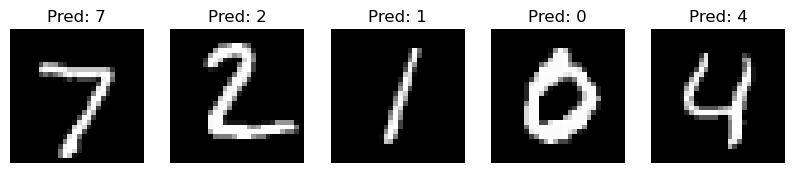

In [17]:
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title(f"Pred: {np.argmax(pred[i])}")
    plt.axis("off")
plt.show()